**Autor:** Andrés Alejandro Rodríguez Lozano  
**Portafolio:** Portafolio de Andrés Alejandro Rodríguez Lozano

# Capítulo 7 — Rolling returns

Retorno anualizado en ventanas móviles de 36 meses (y 60 meses).


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%config InlineBackend.figure_formats = ['svg']
plt.rcParams.update({
    'figure.dpi': 72,
    'savefig.dpi': 72,
    'figure.figsize': (8, 3.8),
    'font.size': 9,
    'svg.fonttype': 'none',
    'path.simplify': True,
    'path.simplify_threshold': 0.2,
})

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'src'))
import portfolio_utils as pu

def load_monthly():
    """Carga precios mensuales: cache mensual, diario, o yfinance."""
    mpath = ROOT / 'data' / 'precios_mensuales.csv'
    if mpath.exists():
        print('Precios mensuales (cache):', mpath.name)
        return pd.read_csv(mpath, index_col=0, parse_dates=True).loc[: '2026-09-30']
    csv = ROOT / 'data' / 'precios_ajustados_diarios.csv'
    if csv.exists():
        daily = pd.read_csv(csv, index_col=0, parse_dates=True)
        print('Precios diarios (cache):', csv.name)
        return pu.to_month_end(daily).loc[: '2026-09-30']
    tickers = sorted(set(list(pu.CURRENT_WEIGHTS) + [pu.BENCHMARK]))
    print('Descargando precios con yfinance…')
    daily = pu.download_prices(tickers)
    return pu.to_month_end(daily).loc[: '2026-09-30']


monthly = load_monthly()
bt = pu.backtest_portfolio(monthly, pu.CURRENT_WEIGHTS, start='2016-01-31', end='2026-09-30', rebalance='A')
spy = pu.backtest_portfolio(monthly, {'SPY': 1}, start='2016-01-31', end='2026-09-30', rebalance='N')
roll3_p = pu.rolling_cagr(bt['value'], 36)
roll3_s = pu.rolling_cagr(spy['value'], 36)
roll5_p = pu.rolling_cagr(bt['value'], 60)
print('Último rolling 36m portafolio:', f"{100*float(roll3_p.dropna().iloc[-1]):.2f}%")
print('Último rolling 36m SPY       :', f"{100*float(roll3_s.dropna().iloc[-1]):.2f}%")


Precios mensuales (cache): precios_mensuales.csv
Último rolling 36m portafolio: 33.86%
Último rolling 36m SPY       : 24.41%


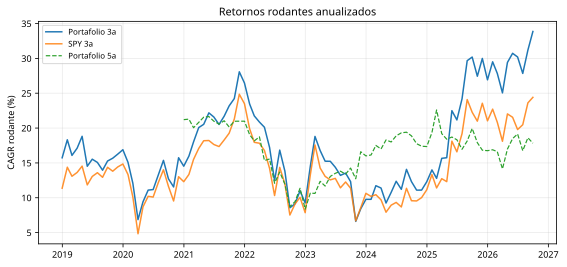

In [2]:
# Rolling CAGR
fig, ax = plt.subplots()
ax.plot(roll3_p.index, roll3_p * 100, label='Portafolio 3a', lw=1.5)
ax.plot(roll3_s.index, roll3_s * 100, label='SPY 3a', lw=1.5, alpha=0.85)
ax.plot(roll5_p.index, roll5_p * 100, label='Portafolio 5a', ls='--', lw=1.2)
ax.set_ylabel('CAGR rodante (%)')
ax.set_title('Retornos rodantes anualizados')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


## Conclusiones
1. El outperformance no es uniforme; depende de la ventana.

## Ejercicios
1. Ventana 12m vs 60m.
2. % de ventanas con portafolio > SPY.
